In [2]:
import pandas as pd

jobs_adzuna = pd.read_csv("../Sofia/jobs_adzuna_analysis.csv")
jobs_github = pd.read_csv("../MG/final_jobs.csv")

combined = pd.concat([jobs_adzuna, jobs_github], ignore_index=True)

combined.to_csv("combined.csv", index=False)



In [3]:
print(combined.shape)
print(combined.head())
print(combined["job_title"].value_counts())


(1857, 6)
   date     job_title  salary_in_usd work_mode country  \
0  2025         Other        52996.0    onsite      GB   
1  2025  Data Analyst        50000.0    hybrid      GB   
2  2025  Data Analyst        24000.0    onsite      GB   
3  2025  Data Analyst        35000.0    onsite      GB   
4  2025  Data Analyst        43779.0    onsite      GB   

                                        skills  
0                                        ['r']  
1  ['excel', 'power bi', 'python', 'r', 'sql']  
2                                        ['r']  
3                                        ['r']  
4                                        ['r']  
job_title
Data Analyst                  775
Other                         464
Data Engineer                 284
Data Scientist                270
Machine Learning Developer     62
Machine Learning                2
Name: count, dtype: int64


In [4]:
#drop rows where job_title is "Other":

combined = combined[combined["job_title"] != "Other"]
combined['job_title'] = combined['job_title'].replace('Machine Learning', 'Machine Learning Developer')
print(combined["job_title"].value_counts())
print(combined.shape)


job_title
Data Analyst                  775
Data Engineer                 284
Data Scientist                270
Machine Learning Developer     64
Name: count, dtype: int64
(1393, 6)


In [5]:
combined

,date,job_title,salary_in_usd,work_mode,country,skills
1,2025,Data Analyst,50000.0,hybrid,GB,"['excel', 'power bi', 'python', 'r', 'sql']"
2,2025,Data Analyst,24000.0,onsite,GB,['r']
3,2025,Data Analyst,35000.0,onsite,GB,['r']
4,2025,Data Analyst,43779.0,onsite,GB,['r']
5,2025,Data Analyst,25904.0,onsite,GB,['r']
...,...,...,...,...,...,...
1852,2022,Data Engineer,154000.0,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
1853,2022,Data Engineer,126000.0,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
1854,2022,Data Analyst,129000.0,on_site,US,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."
1855,2022,Data Analyst,150000.0,remote,US,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."


In [6]:
import ast

skills_map = {
    'Data Scientist': [
        'Python', 'R',
        'Statistics',
        'Machine learning',
        'Data cleaning',
        'SQL',
        'Visualization (e.g. Tableau)',
        'Big data (e.g. Spark)',
        'Model validation',
        'Communication',
        'Domain knowledge'
    ],
    'Machine Learning Developer': [
        'Python', 'C++',
        'TensorFlow', 'PyTorch',
        'ML algorithms',
        'Data pipelines',
        'Deployment',
        'Cloud (AWS, GCP)',
        'Git',
        'Math',
        'Experiment tracking',
        'Software practices'
    ],
    'Data Engineer': [
        'Python', 'Java', 'Scala',
        'SQL', 'NoSQL',
        'ETL', 'pipelines',
        'Spark', 'Kafka',
        'Airflow',
        'Cloud platforms',
        'Data modeling',
        'Docker', 'Kubernetes',
        'APIs',
        'Linux'
    ],
    'Data Analyst': [
        'SQL',
        'Excel',
        'Python', 'R',
        'Tableau', 'Power BI',
        'Statistics',
        'Cleaning data',
        'Reporting',
        'Communication',
        'Business insight',
        'Critical thinking'
    ]
}


# Ensure 'skills' column is in list format
combined['skills'] = combined['skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Replace rows where skills == ['r']
def replace_r_skills(row):
    if row['skills'] == ['r']:
        return skills_map.get(row['job_title'], row['skills'])
    return row['skills']

combined['skills'] = combined.apply(replace_r_skills, axis=1)

combined.to_csv("combined.csv", index=False)



In [7]:
print(combined['job_title'].value_counts())


job_title
Data Analyst                  775
Data Engineer                 284
Data Scientist                270
Machine Learning Developer     64
Name: count, dtype: int64


In [8]:
print(combined[combined['skills'].apply(lambda x: x == ['r'])])


Empty DataFrame
Columns: [date, job_title, salary_in_usd, work_mode, country, skills]
Index: []


In [9]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1393 entries, 1 to 1856
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1393 non-null   int64  
 1   job_title      1393 non-null   object 
 2   salary_in_usd  1010 non-null   float64
 3   work_mode      1393 non-null   object 
 4   country        1393 non-null   object 
 5   skills         1393 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 76.2+ KB


<Axes: >

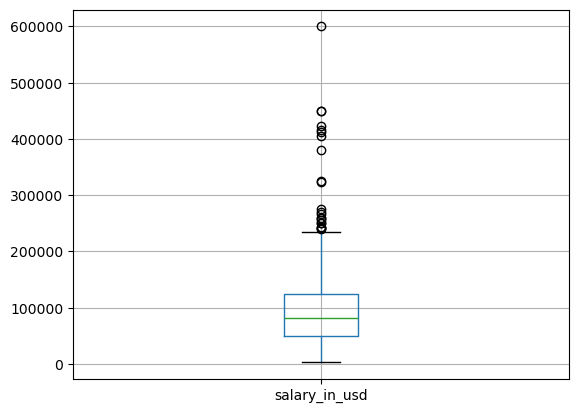

In [10]:
combined.boxplot(column='salary_in_usd')

In [11]:
#Check Summary Statistics
print(combined['salary_in_usd'].describe())


count      1010.000000
mean      95487.340594
std       62510.635287
min        2859.000000
25%       49830.500000
50%       82325.000000
75%      125000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64


In [12]:
#Remove or Flag Outliers

Q1 = combined['salary_in_usd'].quantile(0.25)
Q3 = combined['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

filtered_combined = combined[
    (combined['salary_in_usd'] >= Q1 - 1.5 * IQR) &
    (combined['salary_in_usd'] <= Q3 + 1.5 * IQR)
]


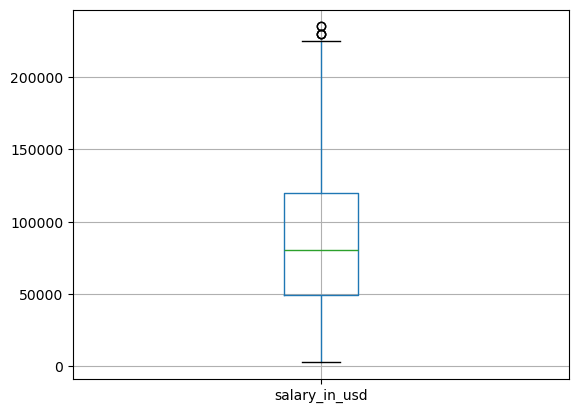

In [13]:
import matplotlib.pyplot as plt

filtered_combined.boxplot(column='salary_in_usd')
plt.show()


In [14]:
print(filtered_combined['salary_in_usd'].describe())


count       988.000000
mean      90285.338057
std       50457.533227
min        2859.000000
25%       49133.500000
50%       80486.500000
75%      120000.000000
max      235000.000000
Name: salary_in_usd, dtype: float64


In [15]:
print(filtered_combined.shape)
print(filtered_combined.head())
print(filtered_combined["job_title"].value_counts())

(988, 6)
   date     job_title  salary_in_usd work_mode country  \
1  2025  Data Analyst        50000.0    hybrid      GB   
2  2025  Data Analyst        24000.0    onsite      GB   
3  2025  Data Analyst        35000.0    onsite      GB   
4  2025  Data Analyst        43779.0    onsite      GB   
5  2025  Data Analyst        25904.0    onsite      GB   

                                              skills  
1                  [excel, power bi, python, r, sql]  
2  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
3  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
4  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
5  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
job_title
Data Analyst                  470
Data Engineer                 233
Data Scientist                225
Machine Learning Developer     60
Name: count, dtype: int64


In [63]:
filtered_combined = filtered_combined.copy()

filtered_combined["work_mode"] = (
    filtered_combined["work_mode"]
    .str.lower()
    .str.strip()
    .replace({
        "onsite" : "on_site",
    })
)

In [64]:
# What is the average salary by job title? 
# Why do some job titles earn more than others?

job_title_salary = (filtered_combined.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False))

job_title_salary

job_title
Data Scientist                105141.071111
Data Engineer                 105107.154506
Machine Learning Developer    102051.633333
Data Analyst                   74323.634043
Name: salary_in_usd, dtype: float64

In [65]:
job_title_salary_2 = (
    filtered_combined
    .groupby("job_title")["salary_in_usd"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False).round(2)
)

job_title_salary_2

,count,mean
job_title,,
Data Scientist,225,105141.07
Data Engineer,233,105107.15
Machine Learning Developer,60,102051.63
Data Analyst,470,74323.63


In [66]:
title_counts = filtered_combined["job_title"].value_counts()

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline  

sns.boxplot(x="job_title", y="salary_in_usd", data=filtered_combined)


<Axes: xlabel='job_title', ylabel='salary_in_usd'>

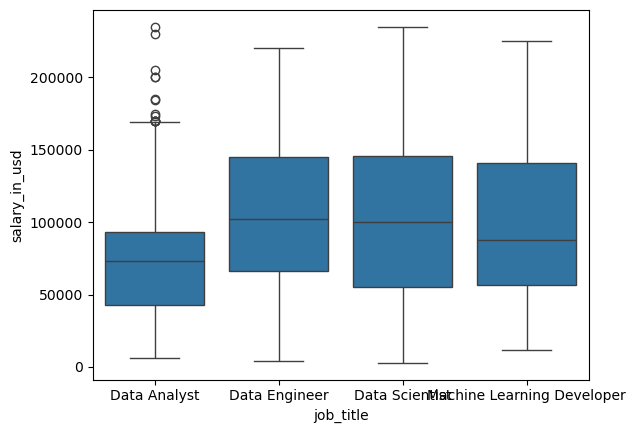

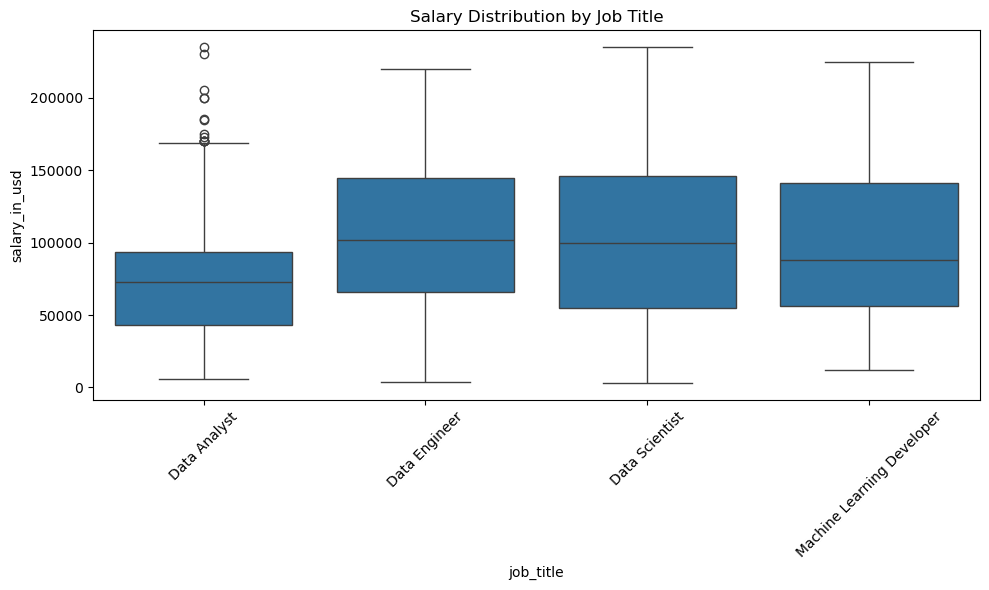

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="job_title", y="salary_in_usd", data=filtered_combined)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Title")
plt.tight_layout()
plt.show()


In [68]:
# Which job titles have the highest average salaries?
# Why are certain roles better paid than others in the data industry?

top_paying_roles = (
    filtered_combined.
    groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
)


df_exploded = filtered_combined.explode("skills")
skill_salary = (
    df_exploded.groupby("skills")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
)

#top_skills = skill_salary.head(20)
#ax = top_skills.plot(kind="barh", figsize=(8, 6), color="orange")
#for i, v in enumerate(top_skills):
 #   ax.text(v + 500, i, f"${v:,.0f}", va='center')


print(top_paying_roles)
print(skill_salary)

job_title
Data Scientist                105141.071111
Data Engineer                 105107.154506
Machine Learning Developer    102051.633333
Data Analyst                   74323.634043
Name: salary_in_usd, dtype: float64
skills
Model validation                104994.397321
Big data (e.g. Spark)           104994.397321
Visualization (e.g. Tableau)    104994.397321
Machine learning                104994.397321
Data cleaning                   104994.397321
Domain knowledge                104994.397321
ETL                             104764.674208
pipelines                       104764.674208
Spark                           104764.674208
Scala                           104764.674208
NoSQL                           104764.674208
Airflow                         104764.674208
Linux                           104764.674208
Kubernetes                      104764.674208
Kafka                           104764.674208
Java                            104764.674208
APIs                            104

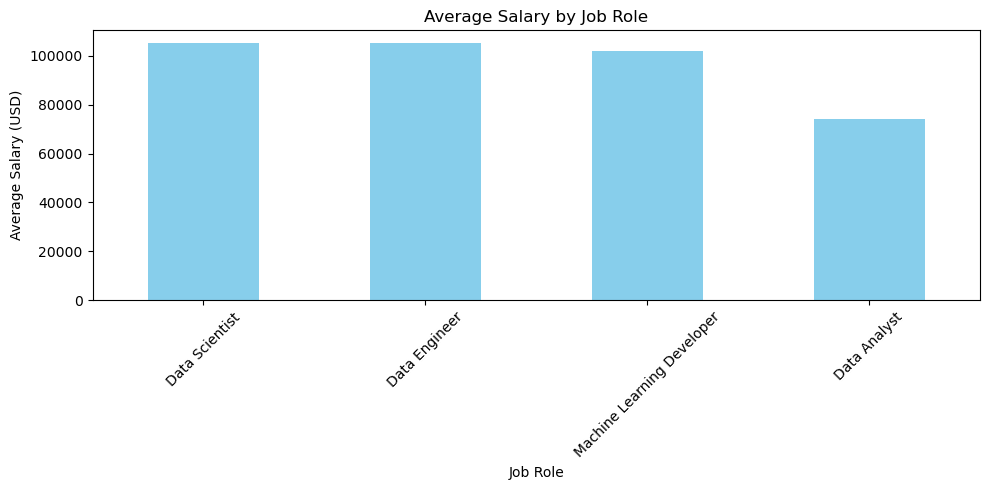

In [69]:
top_paying_roles.plot(kind="bar", figsize=(10, 5), color="skyblue")
plt.title("Average Salary by Job Role")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Job Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

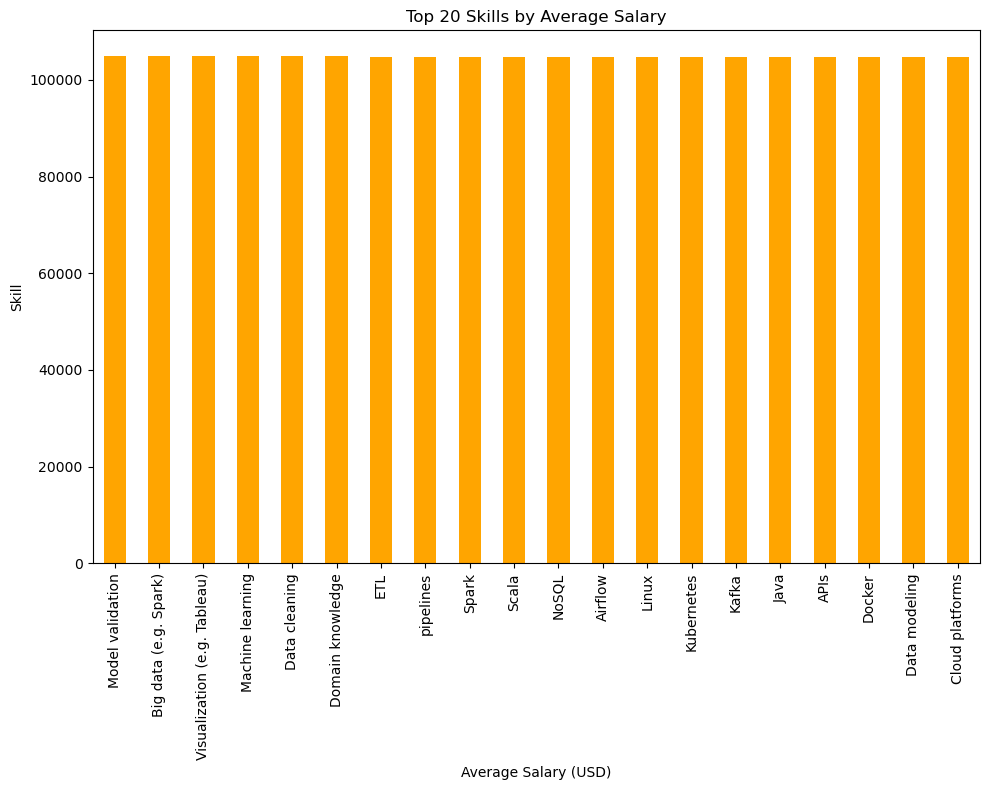

In [70]:
skill_salary.head(20).plot(kind="bar", figsize=(10, 8), color="orange")
plt.title("Top 20 Skills by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [71]:
print(skill_salary.head(30))

skills
Model validation                104994.397321
Big data (e.g. Spark)           104994.397321
Visualization (e.g. Tableau)    104994.397321
Machine learning                104994.397321
Data cleaning                   104994.397321
Domain knowledge                104994.397321
ETL                             104764.674208
pipelines                       104764.674208
Spark                           104764.674208
Scala                           104764.674208
NoSQL                           104764.674208
Airflow                         104764.674208
Linux                           104764.674208
Kubernetes                      104764.674208
Kafka                           104764.674208
Java                            104764.674208
APIs                            104764.674208
Docker                          104764.674208
Data modeling                   104764.674208
Cloud platforms                 104764.674208
Cloud (AWS, GCP)                102504.288136
Math                       

In [72]:
print(skill_salary.describe())



count        54.000000
mean      91172.812610
std       18033.167287
min       29472.000000
25%       75125.530000
50%      102504.288136
75%      104764.674208
max      104994.397321
Name: salary_in_usd, dtype: float64


In [111]:
# Is there salary variation by country?

salary_by_country = (
    filtered_combined
    .groupby("country")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False).head(10).round(2)
)

salary_by_country

country
RU    157500.00
NZ    125000.00
US    119907.76
IL    119059.00
AU    108042.67
IQ    100000.00
DZ    100000.00
AE    100000.00
CA     99823.73
SG     89294.00
Name: salary_in_usd, dtype: float64

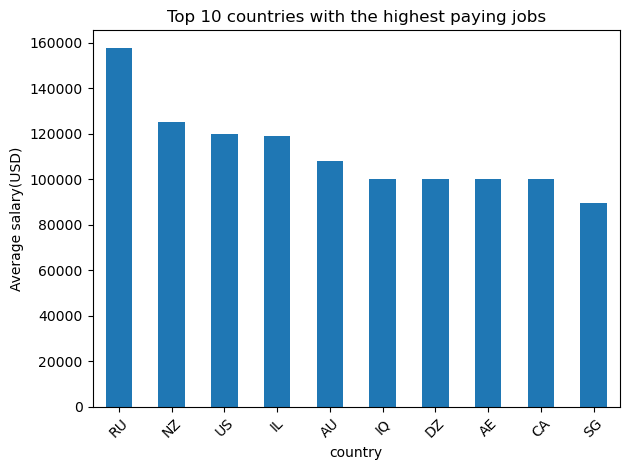

In [120]:
salary_by_country.plot(kind="bar", title= "Top 10 countries with the highest paying jobs")
plt.ylabel("Average salary(USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
# Remote vs. On-site: is there a difference in average salary?
# Why do remote jobs pay more (or less) than on-site jobs?

salary_by_work_mode = filtered_combined.groupby("work_mode")["salary_in_usd"].mean().round(2)

salary_by_work_mode



work_mode
hybrid      75234.34
on_site     76365.40
remote     110884.62
Name: salary_in_usd, dtype: float64

In [75]:
count_by_work_mode = filtered_combined["work_mode"].value_counts()
count_by_work_mode

work_mode
on_site    445
remote     403
hybrid     140
Name: count, dtype: int64

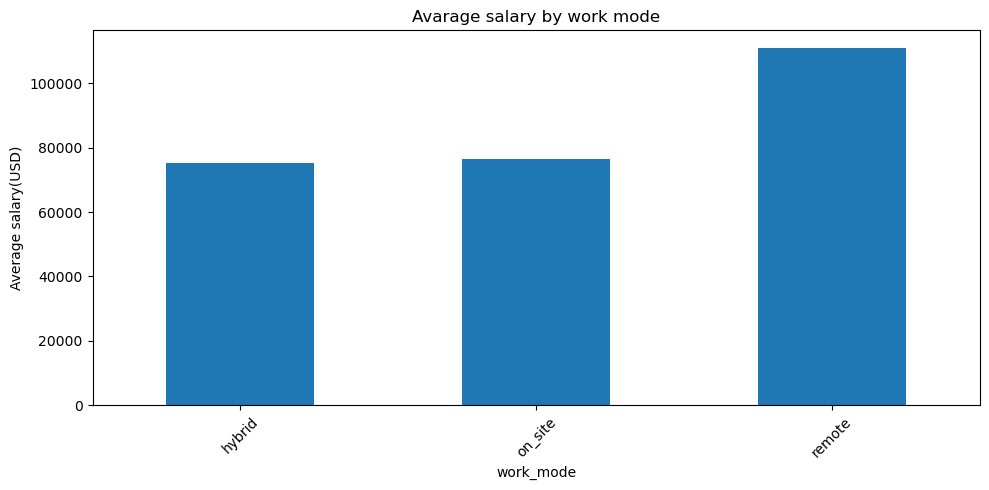

In [76]:
salary_by_work_mode.plot(kind="bar", figsize=(10, 5), title="Avarage salary by work mode")
plt.ylabel("Average salary(USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
# Why are certain roles becoming more popular now?
filtered_combined["year"] = filtered_combined["date"].astype(int)
recent_jobs_2021 = filtered_combined[filtered_combined["year"] == 2021]


emerging_roles_2021 = recent_jobs_2021["job_title"].value_counts().head(10)
print(emerging_roles_2021)

job_title
Data Scientist                85
Data Engineer                 61
Data Analyst                  37
Machine Learning Developer    25
Name: count, dtype: int64


In [96]:
filtered_combined["year"] = filtered_combined["date"].astype(int)
recent_jobs_2022 = filtered_combined[filtered_combined["year"] == 2022]


emerging_roles_2022 = recent_jobs_2022["job_title"].value_counts().head(10)
print(emerging_roles_2022)

job_title
Data Engineer                 102
Data Scientist                 92
Data Analyst                   88
Machine Learning Developer     28
Name: count, dtype: int64


In [97]:
filtered_combined["year"] = filtered_combined["date"].astype(int)
recent_jobs_2025 = filtered_combined[filtered_combined["year"] == 2025]


emerging_roles_2025 = recent_jobs_2025["job_title"].value_counts().head(10)
print(emerging_roles_2025)

job_title
Data Analyst                  332
Data Engineer                  50
Data Scientist                 20
Machine Learning Developer      1
Name: count, dtype: int64


In [ ]:
# ver a evolução ao longo dos anos (2021, 2022 e 2025)

In [92]:
filtered_combined.head()

,date,job_title,salary_in_usd,work_mode,country,skills,year
1,2025,Data Analyst,50000.0,hybrid,GB,"[excel, power bi, python, r, sql]",2025
2,2025,Data Analyst,24000.0,on_site,GB,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2025
3,2025,Data Analyst,35000.0,on_site,GB,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2025
4,2025,Data Analyst,43779.0,on_site,GB,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2025
5,2025,Data Analyst,25904.0,on_site,GB,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2025


In [93]:
filtered_combined.tail()

,date,job_title,salary_in_usd,work_mode,country,skills,year
1852,2022,Data Engineer,154000.0,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin...",2022
1853,2022,Data Engineer,126000.0,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin...",2022
1854,2022,Data Analyst,129000.0,on_site,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2022
1855,2022,Data Analyst,150000.0,remote,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta...",2022
1856,2022,Data Scientist,200000.0,remote,US,"[Python, R, Statistics, Machine learning, Data...",2022


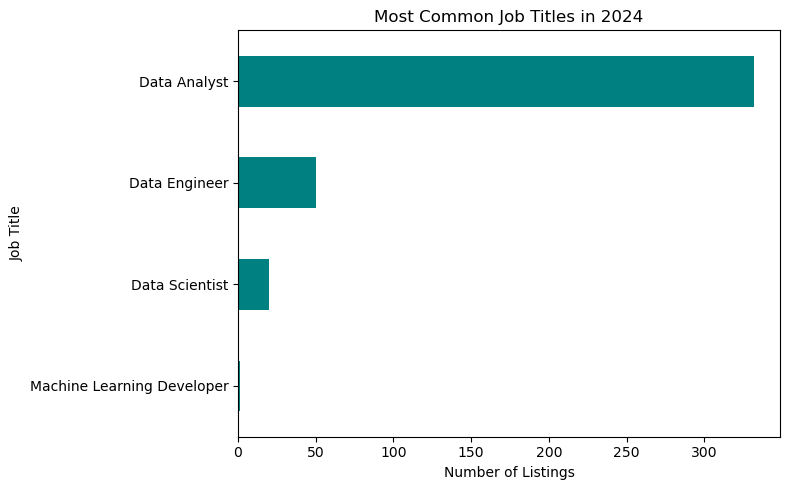

In [ ]:
emerging_roles.plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Most Common Job Titles in 2025")
plt.xlabel("Number of Listings")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
#Most common job title in 2025 and what they are paying


salary_by_role = (
    recent_jobs_2025.groupby("job_title")
    .agg(job_count=("job_title", "count"), avg_salary=("salary_in_usd", "mean"))
    .sort_values(by="job_count", ascending=False)
    .head(10)
)
print(salary_by_role)

                            job_count    avg_salary
job_title                                          
Data Analyst                      332  65184.677711
Data Engineer                      50  99047.200000
Data Scientist                     20  80419.450000
Machine Learning Developer          1  75345.000000


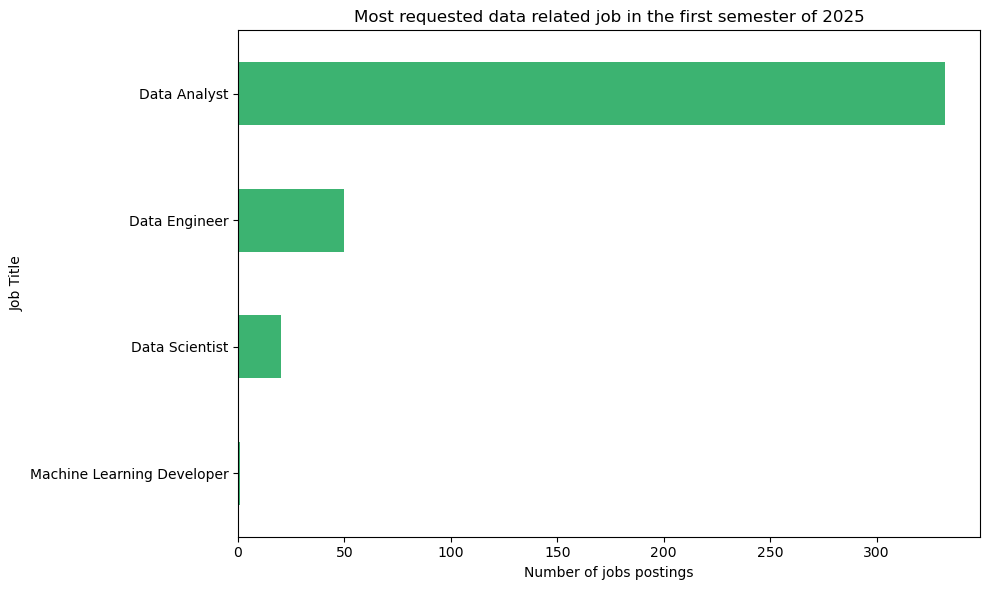

In [119]:
# este não faz sentido, não usar este

salary_by_role["job_count"].plot(kind="barh", figsize=(10, 6), color="mediumseagreen")
plt.title("Most requested data related job in the first semester of 2025")
plt.xlabel("Number of jobs postings")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [103]:
summary_2025 = (
    recent_jobs_2025.groupby("job_title")
    .agg(num_offers=("job_title", "count"), avg_salary=("salary_in_usd", "mean"))
    .sort_values(by="num_offers", ascending=False)
)

print(summary_2025)

                            num_offers    avg_salary
job_title                                           
Data Analyst                       332  65184.677711
Data Engineer                       50  99047.200000
Data Scientist                      20  80419.450000
Machine Learning Developer           1  75345.000000


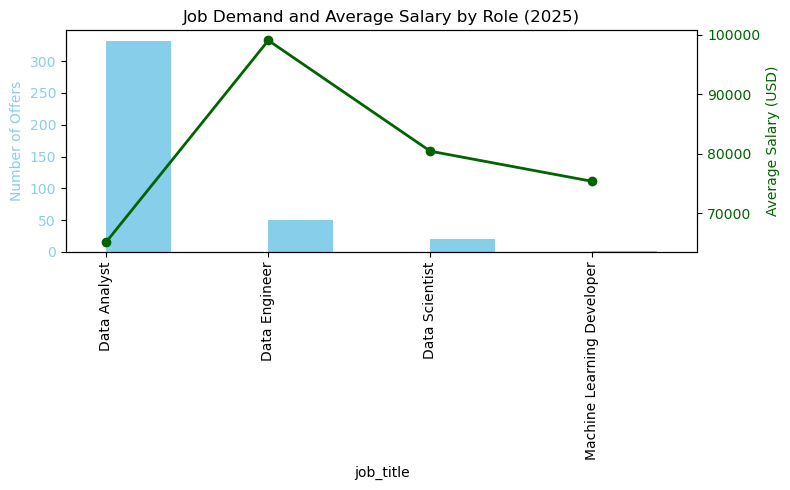

In [109]:
fig, ax1 = plt.subplots(figsize=(8, 5))

summary_2025["num_offers"].plot(kind="bar", color="skyblue", ax=ax1, position=0, width=0.4, label="Number of Offers")
ax1.set_ylabel("Number of Offers", color="skyblue")
ax1.set_title("Job Demand and Average Salary by Role (2025)")
ax1.tick_params(axis='y', labelcolor='skyblue')

# Linha para salário médio
ax2 = ax1.twinx()
summary_2025["avg_salary"].plot(kind="line", color="darkgreen", marker="o", ax=ax2, label="Avg Salary", linewidth=2)
ax2.set_ylabel("Average Salary (USD)", color="darkgreen")
ax2.tick_params(axis='y', labelcolor='darkgreen')

plt.tight_layout()
plt.show()